In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/hp/Downloads/Climate data TSA/DailyDelhiClimateTrain.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df_test = pd.read_csv("C:/Users/hp/Downloads/Climate data TSA/DailyDelhiClimateTest.csv")
df_test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [4]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [7]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
df_test['date'] = pd.to_datetime(df_test['date'])
df_test.set_index('date', inplace=True)

In [9]:
df_test.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333


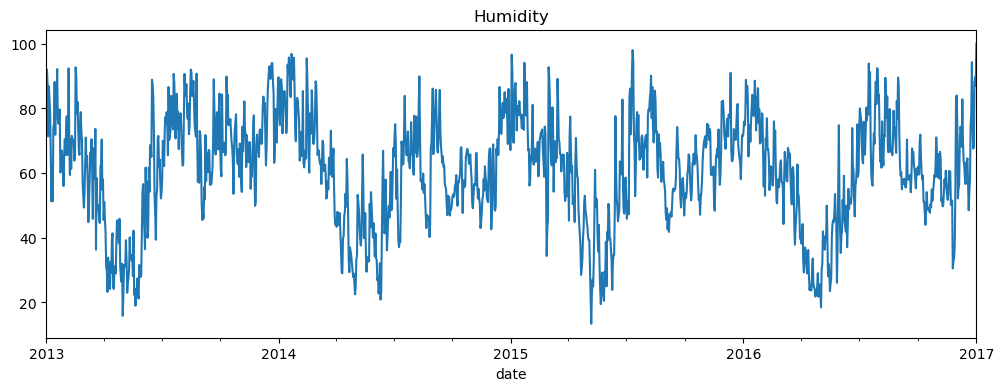

In [10]:
df['humidity'].plot(figsize=(12,4))
plt.title('Humidity')
plt.show()

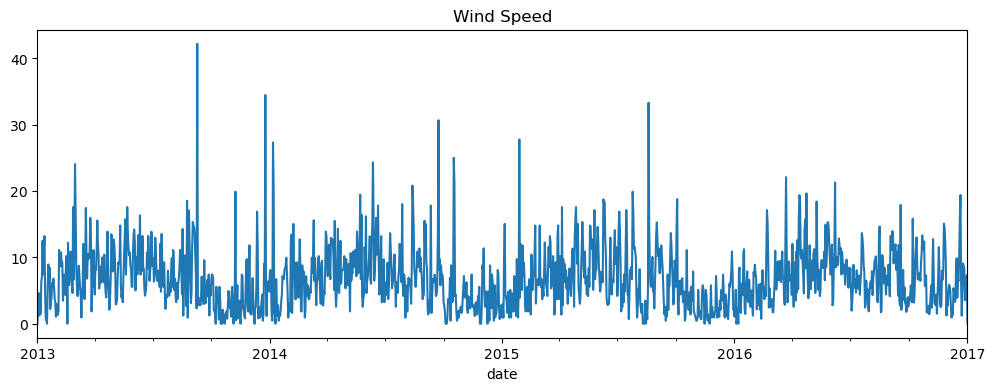

In [11]:
df['wind_speed'].plot(figsize=(12,4))
plt.title('Wind Speed')
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_test(data):
    res = adfuller(data)
    print('ADF static: {}'.format(res[0]))
    print('p-value: {}'.format(res[1]))
    if res[1] <= 0.05:
        print('Reject null hypothesis -> Stationary')
    else:
        print('Not stationary')

In [13]:
adf_test(df['humidity'])

ADF static: -3.6755769191633414
p-value: 0.004470100478130723
Reject null hypothesis -> Stationary


In [14]:
adf_test(df['wind_speed'])

ADF static: -3.8380967566851107
p-value: 0.0025407221531463502
Reject null hypothesis -> Stationary


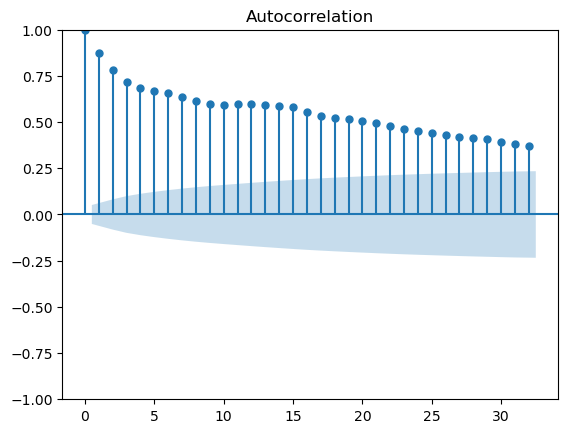

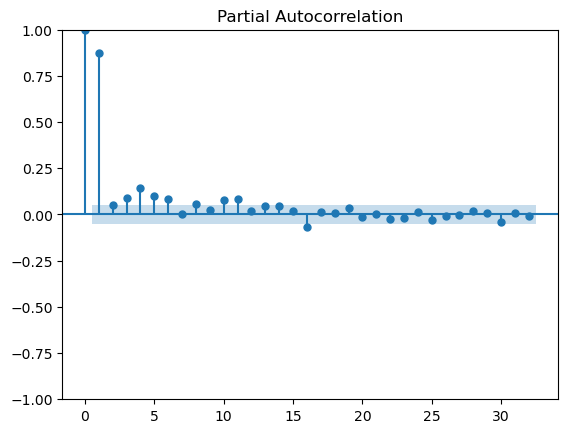

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['humidity'])
plot_pacf(df['humidity'])
plt.show()

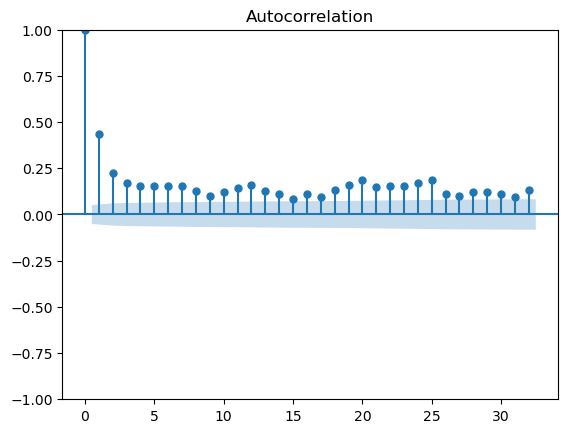

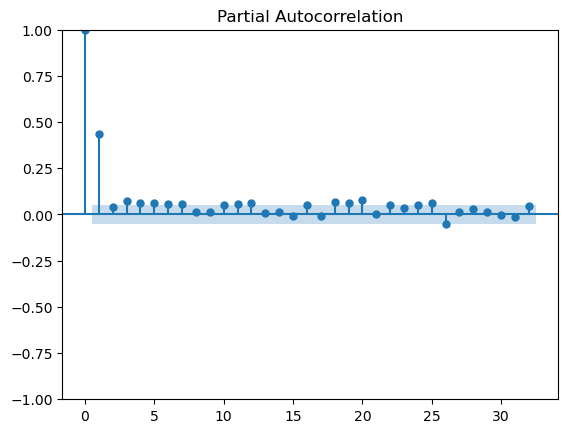

In [16]:
plot_acf(df['wind_speed'])
plot_pacf(df['wind_speed'])
plt.show()

In [17]:
from statsmodels.tsa.arima.model import ARIMA

ma = ARIMA(df['humidity'], order=(8,0,15))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [18]:
fit = ma.fit()

F:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               humidity   No. Observations:                 1462
Model:                ARIMA(8, 0, 15)   Log Likelihood               -5059.331
Date:                Wed, 04 Feb 2026   AIC                          10168.662
Time:                        15:25:55   BIC                          10300.851
Sample:                    01-01-2013   HQIC                         10217.970
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.8375      3.824     15.910      0.000      53.343      68.332
ar.L1          0.7108      0.305      2.329      0.020       0.113       1.309
ar.L2          0.2298      0.339      0.677      0.498      -0.435       0.895
ar.L3         -0.6037      0.332     -1.817      0.069      -1.255       0.047
ar.L4          0.4388      0.391      1.123      0.262      -0.327       1.205
ar.L5          0.0108      0.372      0.029      0.977      -0.718       0.740
ar.L6          0.1160      0.296      0.392      0.695      -0.464       0.696
ar.L7          0.2180      0.291      0.748      0.454      -0.353       0.789
ar.L8         -0.1671      0.244     -0.684      0.494      -0.646       0.312
ma.L1          0.0693      0.307      0.226      0.821      -0.532       0.670
ma.L2         -0.2043      0.262     -0.779      0.436      -0.719       0.310
ma.L3          0.4147      0.234      1.773      0.076      -0.044       0.873
ma.L4         -0.0591      0.297     -0.199      0.842      -0.641       0.523
ma.L5         -0.0319      0.217     -0.147      0.883      -0.457       0.393
ma.L6         -0.0793      0.207     -0.383      0.701      -0.485       0.326
ma.L7         -0.3135      0.199     -1.573      0.116      -0.704       0.077
ma.L8         -0.0340      0.118     -0.289      0.772      -0.264       0.196
ma.L9         -0.0236      0.087     -0.270      0.787      -0.194       0.147
ma.L10        -0.0342      0.062     -0.552      0.581      -0.156       0.087
ma.L11         0.0585      0.052      1.120      0.263      -0.044       0.161
ma.L12         0.0039      0.038      0.102      0.918      -0.071       0.079
ma.L13        -0.0277      0.038     -0.730      0.466      -0.102       0.047
ma.L14         0.0428      0.038      1.122      0.262      -0.032       0.118
ma.L15         0.1002      0.038      2.656      0.008       0.026       0.174
sigma2        59.2751      1.928     30.751      0.000      55.497      63.053
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               153.43
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.66   Skew:                             0.48
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
pred = fit.predict(steps=len(df_test))

In [21]:
res = df_test['humidity'] - pred
res

2013-01-01   NaN
2013-01-02   NaN
2013-01-03   NaN
2013-01-04   NaN
2013-01-05   NaN
              ..
2017-04-20   NaN
2017-04-21   NaN
2017-04-22   NaN
2017-04-23   NaN
2017-04-24   NaN
Length: 1575, dtype: float64

<Axes: ylabel='Density'>

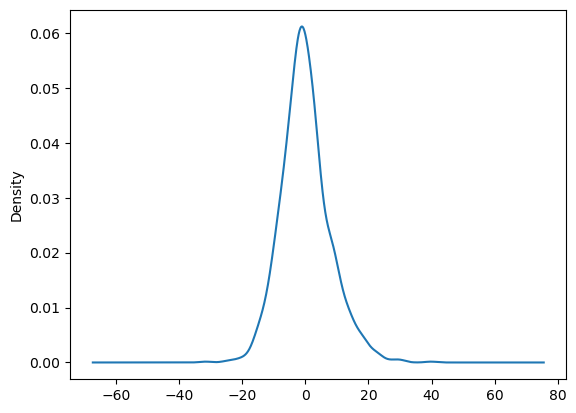

In [22]:
fit.resid.plot(kind='kde')

In [23]:
df['Predicted_humidity'] = pred

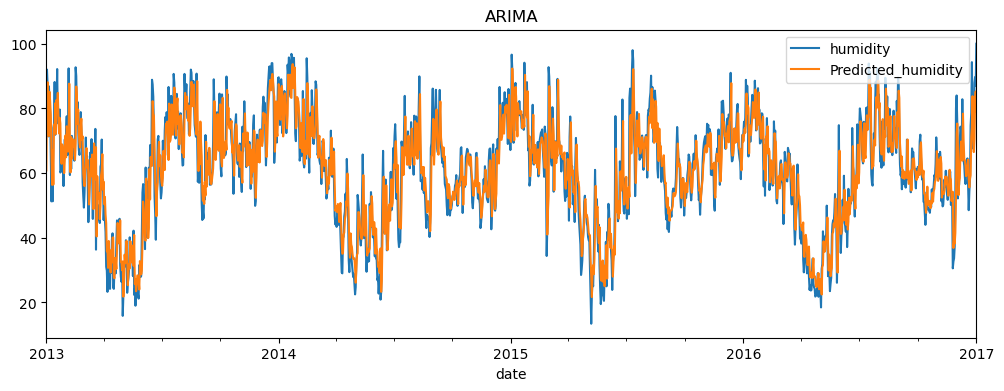

In [24]:
df[['humidity','Predicted_humidity']].plot(figsize=(12,4))
plt.title('ARIMA')
plt.show()

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ms = SARIMAX(df['humidity'], order=(8,0,9), seasonal_order=(0,1,0,12))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [26]:
ms_fit = ms.fit()

F:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [27]:
ms_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                            humidity   No. Observations:                 1462
Model:             SARIMAX(8, 0, 9)x(0, 1, [], 12)   Log Likelihood               -5308.379
Date:                             Wed, 04 Feb 2026   AIC                          10652.757
Time:                                     15:26:22   BIC                          10747.785
Sample:                                 01-01-2013   HQIC                         10688.218
                                      - 01-01-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2802      0.877      0.320      0.749      -1.438       1.999
ar.L2         -0.0700      0.082     -0.850      0.395      -0.231       0.091
ar.L3          0.2361      0.108      2.185      0.029       0.024       0.448
ar.L4         -0.1111      0.179     -0.619      0.536      -0.463       0.241
ar.L5          0.1395      0.052      2.665      0.008       0.037       0.242
ar.L6         -0.3410      0.115     -2.959      0.003      -0.567      -0.115
ar.L7         -0.1022      0.254     -0.402      0.687      -0.600       0.396
ar.L8          0.1081      0.174      0.622      0.534      -0.233       0.449
ma.L1          0.4611      0.878      0.525      0.599      -1.259       2.181
ma.L2          0.3732      0.724      0.516      0.606      -1.046       1.792
ma.L3         -0.2760      0.598     -0.461      0.645      -1.449       0.897
ma.L4          0.1260      0.033      3.866      0.000       0.062       0.190
ma.L5         -0.0170      0.101     -0.168      0.867      -0.215       0.181
ma.L6          0.8424      0.030     27.829      0.000       0.783       0.902
ma.L7          0.4806      0.747      0.643      0.520      -0.984       1.945
ma.L8          0.5058      0.686      0.737      0.461      -0.840       1.851
ma.L9         -0.2931      0.702     -0.418      0.676      -1.669       1.083
sigma2        93.8897      3.480     26.981      0.000      87.069     100.710
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                37.38
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
preds = fit.predict(steps=len(df_test))

In [29]:
ress = df_test['humidity'] - preds
ress

2013-01-01   NaN
2013-01-02   NaN
2013-01-03   NaN
2013-01-04   NaN
2013-01-05   NaN
              ..
2017-04-20   NaN
2017-04-21   NaN
2017-04-22   NaN
2017-04-23   NaN
2017-04-24   NaN
Length: 1575, dtype: float64

<Axes: ylabel='Density'>

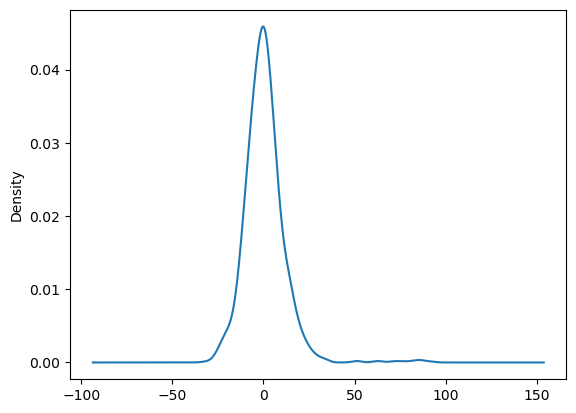

In [30]:
ms_fit.resid.plot(kind='kde')

In [31]:
df['Predicted_humidity_sa'] = preds

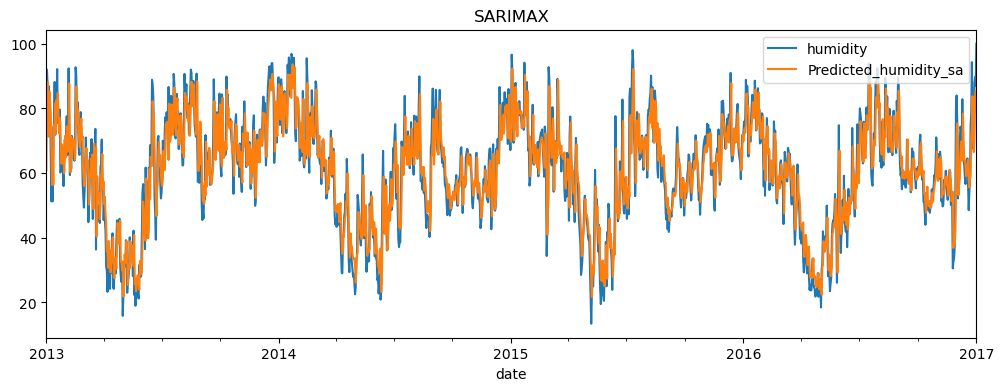

In [32]:
df[['humidity','Predicted_humidity_sa']].plot(figsize=(12,4))
plt.title('SARIMAX')
plt.show()

In [33]:
df.reset_index(inplace=True)
d = df.drop(['wind_speed','meantemp','meanpressure','Predicted_humidity','Predicted_humidity_sa'], axis=1)

In [34]:
d.head()

,date,humidity
0,2013-01-01,84.500000
1,2013-01-02,92.000000
2,2013-01-03,87.000000
3,2013-01-04,71.333333
4,2013-01-05,86.833333


In [40]:
d.rename(columns={'date':'ds', 'humidity':'y'}, inplace=True)
d.head()

,ds,y
0,2013-01-01,84.500000
1,2013-01-02,92.000000
2,2013-01-03,87.000000
3,2013-01-04,71.333333
4,2013-01-05,86.833333


In [41]:
from prophet import Prophet
mp = Prophet()

In [43]:
mp.fit(d)

15:30:57 - cmdstanpy - INFO - Chain [1] start processing
15:30:58 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
mp.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [46]:
future = mp.make_future_dataframe(periods=365)
future.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [47]:
predp = mp.predict(future)
predp.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,58.801632,63.408194,88.872085,58.801632,58.801632,16.897612,16.897612,16.897612,-0.264365,-0.264365,-0.264365,17.161977,17.161977,17.161977,0.0,0.0,0.0,75.699244
1,2013-01-02,58.823720,63.171013,88.884178,58.823720,58.823720,16.776431,16.776431,16.776431,-0.731204,-0.731204,-0.731204,17.507635,17.507635,17.507635,0.0,0.0,0.0,75.600151
2,2013-01-03,58.845808,63.110938,87.912652,58.845808,58.845808,16.764687,16.764687,16.764687,-1.095644,-1.095644,-1.095644,17.860331,17.860331,17.860331,0.0,0.0,0.0,75.610495
3,2013-01-04,58.867896,63.793017,90.332018,58.867896,58.867896,18.040120,18.040120,18.040120,-0.173628,-0.173628,-0.173628,18.213748,18.213748,18.213748,0.0,0.0,0.0,76.908016
4,2013-01-05,58.889984,64.449874,91.532823,58.889984,58.889984,19.800774,19.800774,19.800774,1.239979,1.239979,1.239979,18.560795,18.560795,18.560795,0.0,0.0,0.0,78.690758


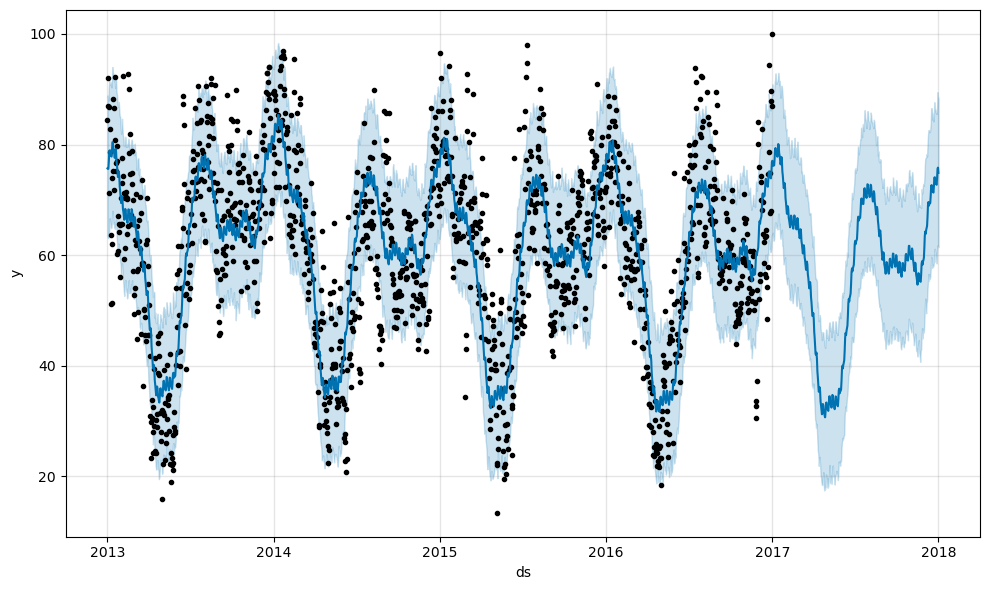

In [50]:
mp.plot(predp)
plt.show()

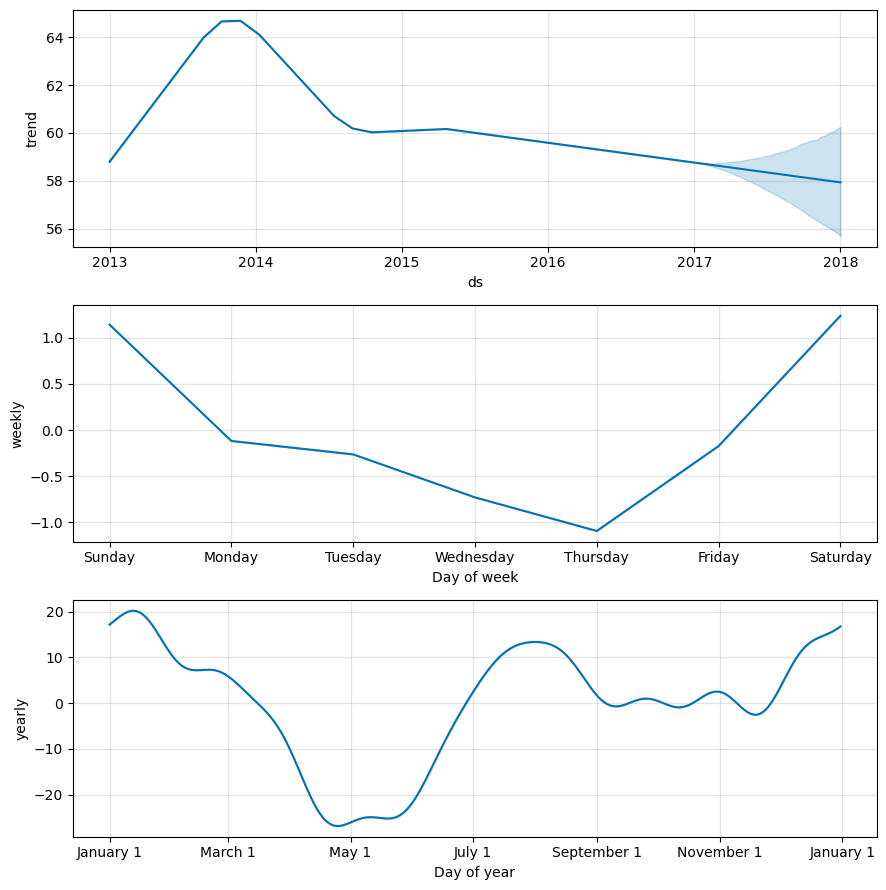

In [51]:
mp.plot_components(predp)
plt.show()

In [52]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(mp, initial='730 days', period='180 days', horizon='365 days')
df_cv.head()

  0%|          | 0/3 [00:00<?, ?it/s]

15:33:36 - cmdstanpy - INFO - Chain [1] start processing
15:33:36 - cmdstanpy - INFO - Chain [1] done processing
15:33:37 - cmdstanpy - INFO - Chain [1] start processing
15:33:37 - cmdstanpy - INFO - Chain [1] done processing
15:33:37 - cmdstanpy - INFO - Chain [1] start processing
15:33:37 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-08,73.633026,61.673108,85.484693,87.875,2015-01-07
1,2015-01-09,75.293405,61.353935,87.653120,80.625,2015-01-07
2,2015-01-10,76.052345,63.574092,88.436792,73.125,2015-01-07
3,2015-01-11,74.865745,63.442281,88.154998,80.750,2015-01-07
4,2015-01-12,73.070373,61.412532,85.872320,79.500,2015-01-07


In [53]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,92.135528,9.598725,7.348294,0.099022,0.080876,0.099592,0.828746
1,38 days,89.201005,9.444628,7.177700,0.097089,0.080853,0.097396,0.834862
2,39 days,87.511201,9.354742,7.081337,0.096109,0.079427,0.096224,0.840979
3,40 days,86.286393,9.289047,7.125890,0.097763,0.080853,0.097344,0.831804
4,41 days,80.726114,8.984771,7.051378,0.098112,0.080976,0.097043,0.831804


F:\Anaconda3\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
F:\Anaconda3\Lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


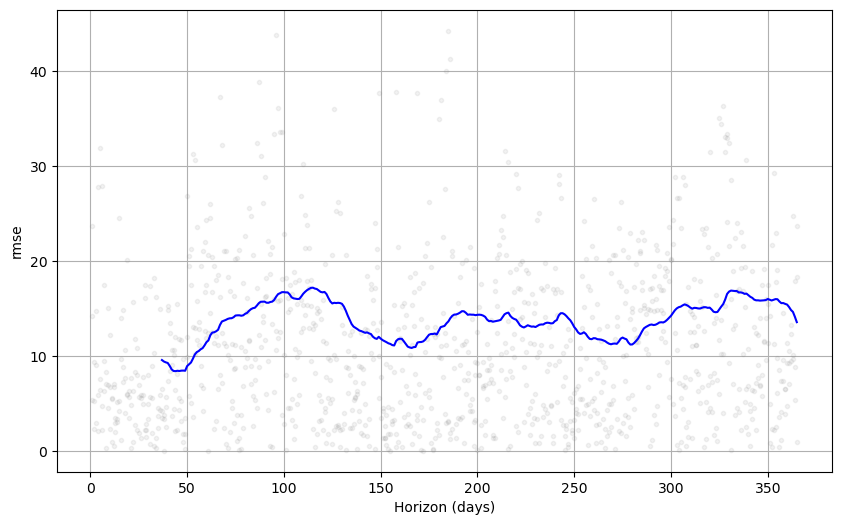

In [54]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

### Glod Prices

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df = pd.read_csv("C:/Users/hp/Downloads/Datasets/gold_monthly_tsa.csv")
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    847 non-null    object 
 1   Price   847 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.4+ KB


In [101]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [102]:
df.head()

,Price
Date,
1950-01-01,34.73
1950-02-01,34.73
1950-03-01,34.73
1950-04-01,34.73
1950-05-01,34.73


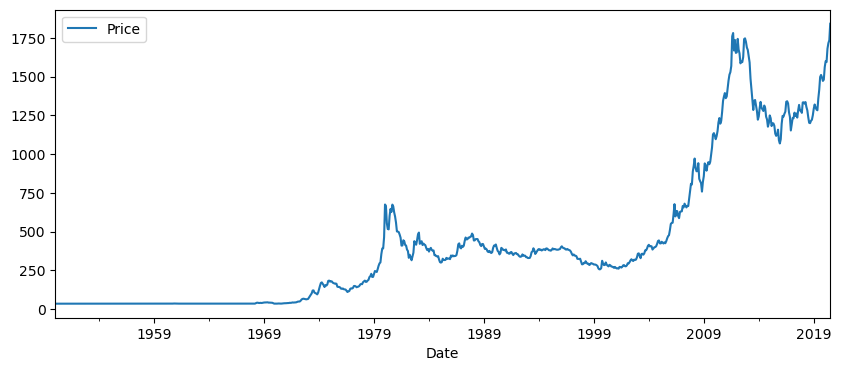

In [103]:
df.plot(figsize=(10,4))
plt.show()

upward trend, no seasonality visible here

In [104]:
from statsmodels.tsa.stattools import adfuller

def adf_test(data):
    res = adfuller(data)
    print('ADF stat: {}'.format(res[0]))
    print('p-value; {}'.format(res[1]))
    if res[1] <= 0.05:
        print('reject null hypothesis, stationary data')
    else:
        print('not stationary')

In [105]:
adf_test(df)

ADF stat: 0.8143240077835305
p-value; 0.9918639010465632
not stationary


In [106]:
df['first difference'] = df['Price'] - df['Price'].shift(1)

In [107]:
df.head()

,Price,first difference
Date,,
1950-01-01,34.73,NaN
1950-02-01,34.73,0.0
1950-03-01,34.73,0.0
1950-04-01,34.73,0.0
1950-05-01,34.73,0.0


In [108]:
adf_test(df['first difference'].dropna())

ADF stat: -6.217086926407326
p-value; 5.3332825133424927e-08
reject null hypothesis, stationary data


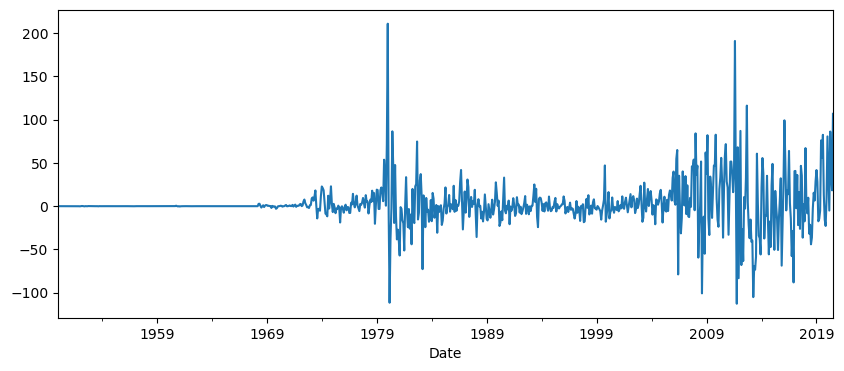

In [109]:
df['first difference'].plot(figsize=(10,4))
plt.show()

In [110]:
df

,Price,first difference
Date,,
1950-01-01,34.730,NaN
1950-02-01,34.730,0.000
1950-03-01,34.730,0.000
1950-04-01,34.730,0.000
1950-05-01,34.730,0.000
...,...,...
2020-03-01,1593.764,-5.054
2020-04-01,1680.030,86.266
2020-05-01,1715.697,35.667


In [111]:
df.resample(rule='YE').max()

,Price,first difference
Date,,
1950-12-31,34.730,0.000
1951-12-31,34.730,0.020
1952-12-31,34.820,0.190
1953-12-31,34.950,0.090
1954-12-31,35.080,0.120
...,...,...
2016-12-31,1340.861,99.238
2017-12-31,1317.045,46.620
2018-12-31,1335.332,67.135


In [112]:
df.resample(rule='BQS').max()

,Price,first difference
Date,,
1949-10-03,34.730,NaN
1950-01-02,34.730,0.000
1950-04-03,34.730,0.000
1950-07-03,34.730,0.000
1950-10-02,34.730,0.000
...,...,...
2019-07-01,1510.336,82.491
2019-10-01,1494.765,8.104
2020-01-01,1598.818,80.643


<Axes: xlabel='Date'>

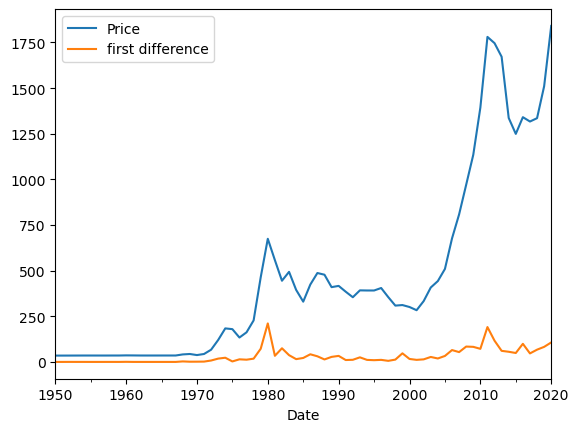

In [24]:
df.resample(rule='YE').max().plot()

<Axes: xlabel='Date'>

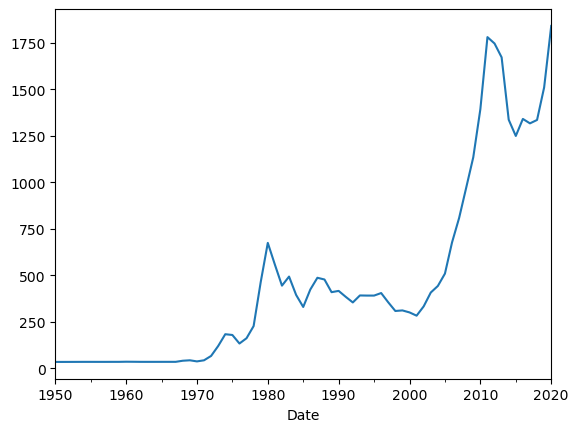

In [113]:
df['Price'].resample(rule='YE').max().plot()

In [114]:
df['Price'].rolling(window=3).mean()

Date
1950-01-01            NaN
1950-02-01            NaN
1950-03-01      34.730000
1950-04-01      34.730000
1950-05-01      34.730000
                 ...     
2020-03-01    1584.416667
2020-04-01    1624.204000
2020-05-01    1663.163667
2020-06-01    1709.919667
2020-07-01    1763.512000
Name: Price, Length: 847, dtype: float64

In [115]:
df['1 year rolling price'] = df['Price'].rolling(12).mean()
df.head()

,Price,first difference,1 year rolling price
Date,,,
1950-01-01,34.73,NaN,NaN
1950-02-01,34.73,0.0,NaN
1950-03-01,34.73,0.0,NaN
1950-04-01,34.73,0.0,NaN
1950-05-01,34.73,0.0,NaN


In [116]:
df['1 year rolling price']

Date
1950-01-01            NaN
1950-02-01            NaN
1950-03-01            NaN
1950-04-01            NaN
1950-05-01            NaN
                 ...     
2020-03-01    1462.550667
2020-04-01    1495.249000
2020-05-01    1531.352083
2020-06-01    1562.647417
2020-07-01    1598.163750
Name: 1 year rolling price, Length: 847, dtype: float64

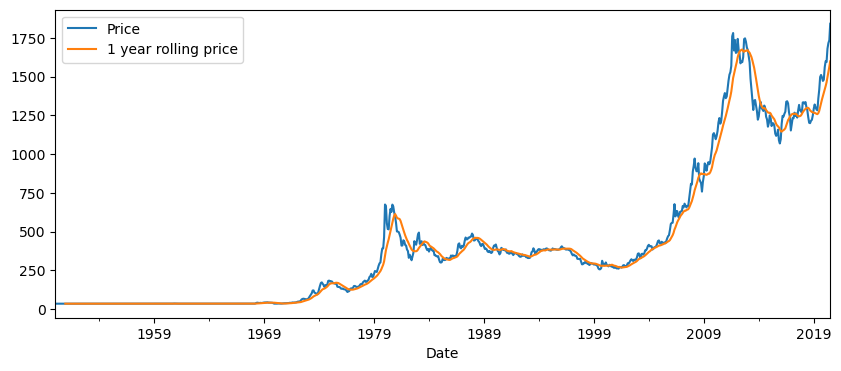

In [117]:
df[['Price','1 year rolling price']].plot(figsize=(10,4))
plt.show()

In [118]:
df['4 months rolling'] = df['Price'].rolling(window=4, min_periods=1).mean()
df['4 months rolling']

Date
1950-01-01      34.73000
1950-02-01      34.73000
1950-03-01      34.73000
1950-04-01      34.73000
1950-05-01      34.73000
                 ...    
2020-03-01    1558.31875
2020-04-01    1608.32000
2020-05-01    1647.07725
2020-06-01    1680.88075
2020-07-01    1742.64150
Name: 4 months rolling, Length: 847, dtype: float64

<Axes: xlabel='Date'>

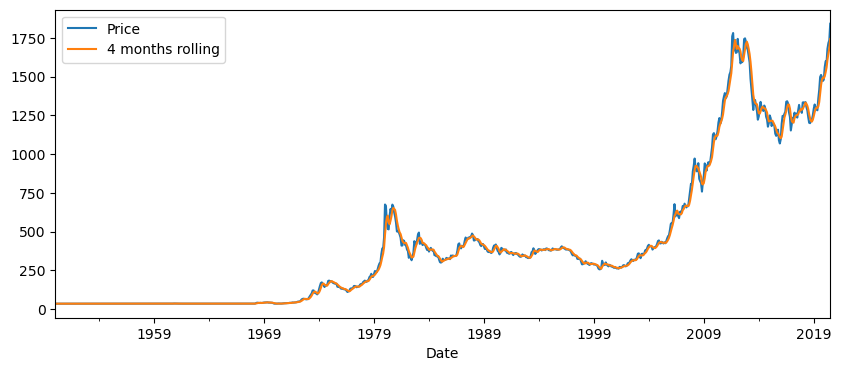

In [119]:
df[['Price','4 months rolling']].plot(figsize=(10,4))

In [120]:
df['6 months rolling'] = df['Price'].rolling(window=6, min_periods=1).mean()

<Axes: xlabel='Date'>

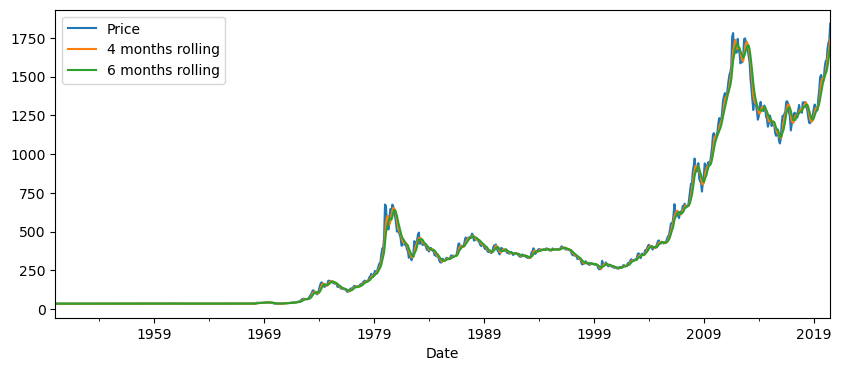

In [121]:
df[['Price','4 months rolling','6 months rolling']].plot(figsize=(10,4))

In [122]:
df['ema_0.1'] = df['Price'].ewm(alpha=0.1, adjust=False).mean()

<Axes: xlabel='Date'>

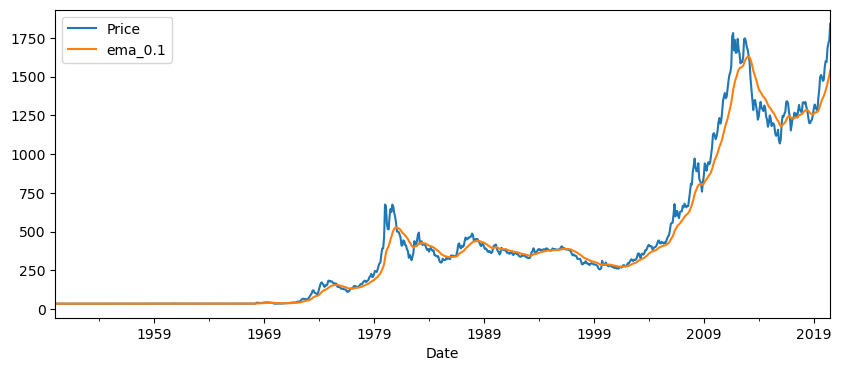

In [123]:
df[['Price','ema_0.1']].plot(figsize=(10,4))

In [124]:
import statsmodels.api as sms
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

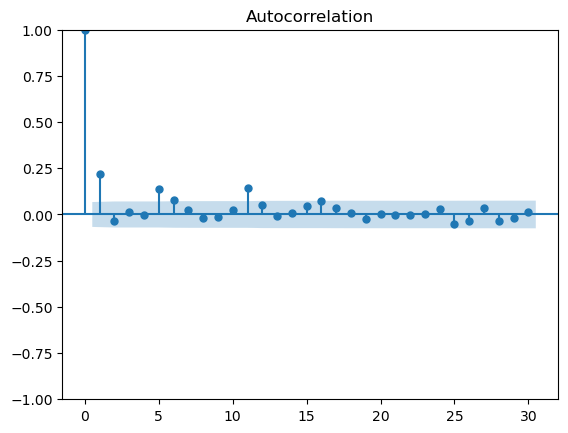

In [126]:
acf = plot_acf(df['first difference'].dropna())

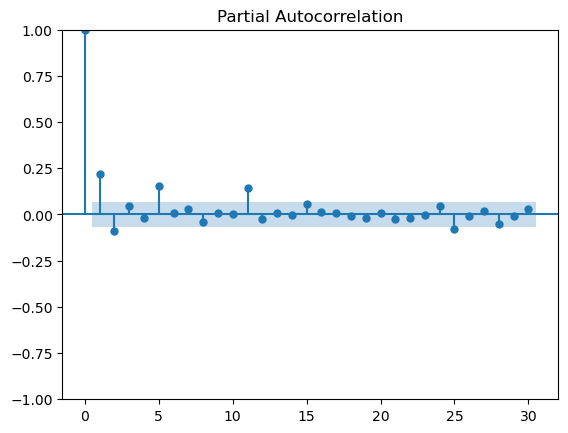

In [127]:
pacf = plot_pacf(df['first difference'].dropna())

In [128]:
from datetime import datetime, timedelta
train_end = datetime(2000,1,1)
test_end = datetime(2020,7,1)

In [129]:
train_data = df[:train_end]
test_data = df[train_end+timedelta(days=1):test_end]

In [130]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [131]:
from statsmodels.tsa.arima.model import ARIMA
ma = ARIMA(train_data['Price'], order=(2,1,2))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [132]:
fit = ma.fit()

In [133]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                  601
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2451.809
Date:                Fri, 06 Feb 2026   AIC                           4913.617
Time:                        17:57:00   BIC                           4935.602
Sample:                    01-01-1950   HQIC                          4922.175
                         - 01-01-2000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0336      0.270      0.124      0.901      -0.496       0.564
ar.L2          0.0972      0.131      0.742      0.458      -0.160       0.354
ma.L1          0.3253      0.269      1.210      0.226      -0.202       0.852
ma.L2         -0.3203      0.216     -1.482      0.138      -0.744       0.103
sigma2       207.3066      3.415     60.702      0.000     200.613     214.000
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             66640.58
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):           34424.58   Skew:                             3.82
Prob(H) (two-sided):                  0.00   Kurtosis:                        54.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [134]:
pred = fit.predict(steps=len(test_data))
res = test_data['Price'] - pred

<Axes: ylabel='Density'>

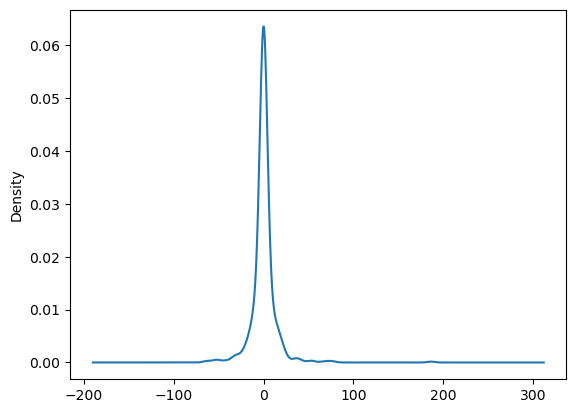

In [135]:
fit.resid.plot(kind='kde')

peak around 0, normally distributed, narrow curve, tall peak -> very less errors in predictions

In [136]:
df['predicted price'] = pred

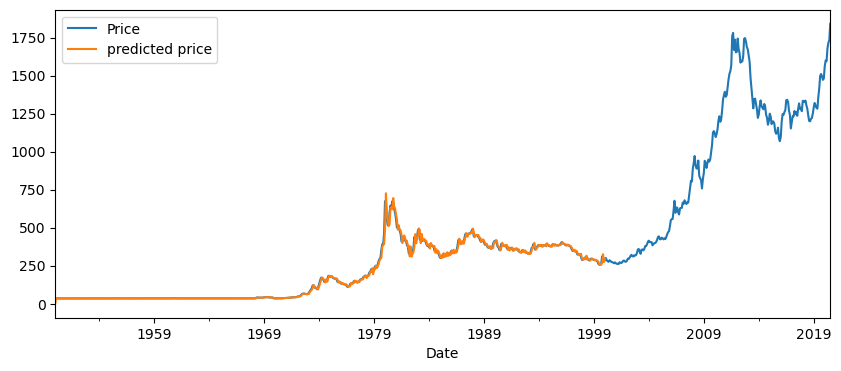

In [137]:
df[['Price','predicted price']].plot(figsize=(10,4))
plt.show()

In [138]:
df.head()

,Price,first difference,1 year rolling price,4 months rolling,6 months rolling,ema_0.1,predicted price
Date,,,,,,,
1950-01-01,34.73,NaN,NaN,34.73,34.73,34.73,0.000000
1950-02-01,34.73,0.0,NaN,34.73,34.73,34.73,34.731992
1950-03-01,34.73,0.0,NaN,34.73,34.73,34.73,34.728114
1950-04-01,34.73,0.0,NaN,34.73,34.73,34.73,34.731029
1950-05-01,34.73,0.0,NaN,34.73,34.73,34.73,34.729157


In [139]:
df.reset_index(inplace=True)
d = df.drop(['first difference','1 year rolling price','4 months rolling','6 months rolling','ema_0.1','predicted price'], axis=1)

In [140]:
d.head()

,Date,Price
0,1950-01-01,34.73
1,1950-02-01,34.73
2,1950-03-01,34.73
3,1950-04-01,34.73
4,1950-05-01,34.73


In [141]:
d.rename(columns={'Date':'ds', 'Price':'y'}, inplace=True)
d.head()

,ds,y
0,1950-01-01,34.73
1,1950-02-01,34.73
2,1950-03-01,34.73
3,1950-04-01,34.73
4,1950-05-01,34.73


In [142]:
from prophet import Prophet
mp = Prophet()

In [143]:
mp.fit(d)

17:59:37 - cmdstanpy - INFO - Chain [1] start processing
17:59:38 - cmdstanpy - INFO - Chain [1] done processing


In [144]:
mp.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [150]:
future  = mp.make_future_dataframe(periods=70, freq='ME')
future.head()

,ds
0,1950-01-01
1,1950-02-01
2,1950-03-01
3,1950-04-01
4,1950-05-01


In [151]:
predp = mp.predict(future)
predp.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1950-01-01,24.901290,-164.426931,199.281069,24.901290,24.901290,-8.042187,-8.042187,-8.042187,-8.042187,-8.042187,-8.042187,0.0,0.0,0.0,16.859104
1,1950-02-01,25.049401,-157.767981,199.759919,25.049401,25.049401,-8.166377,-8.166377,-8.166377,-8.166377,-8.166377,-8.166377,0.0,0.0,0.0,16.883023
2,1950-03-01,25.183178,-161.231824,184.368087,25.183178,25.183178,-12.449217,-12.449217,-12.449217,-12.449217,-12.449217,-12.449217,0.0,0.0,0.0,12.733960
3,1950-04-01,25.331288,-148.629027,205.408055,25.331288,25.331288,-10.149320,-10.149320,-10.149320,-10.149320,-10.149320,-10.149320,0.0,0.0,0.0,15.181968
4,1950-05-01,25.474620,-180.824280,179.297058,25.474620,25.474620,-8.658331,-8.658331,-8.658331,-8.658331,-8.658331,-8.658331,0.0,0.0,0.0,16.816290


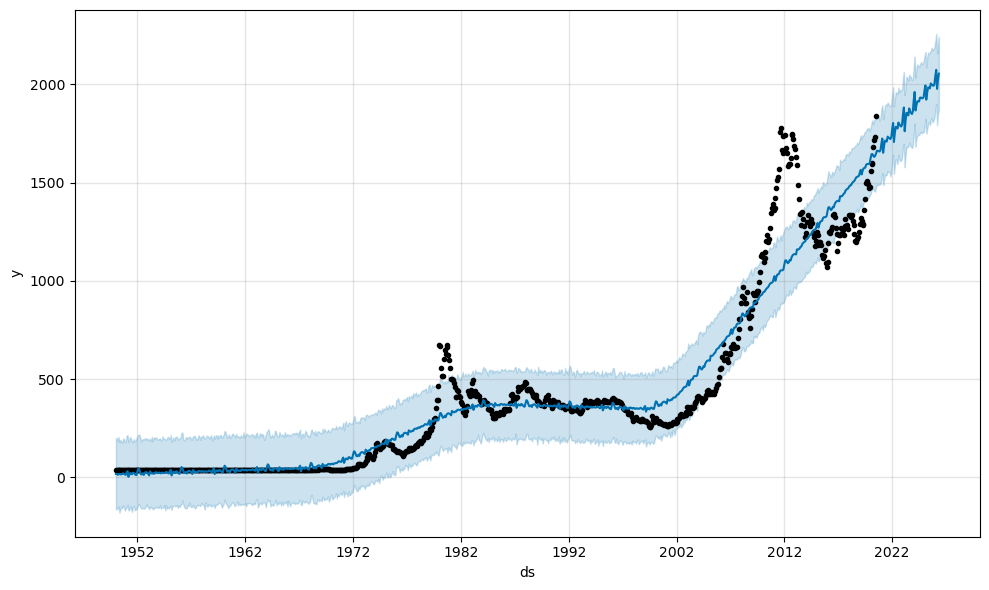

In [152]:
mp.plot(predp)
plt.show()

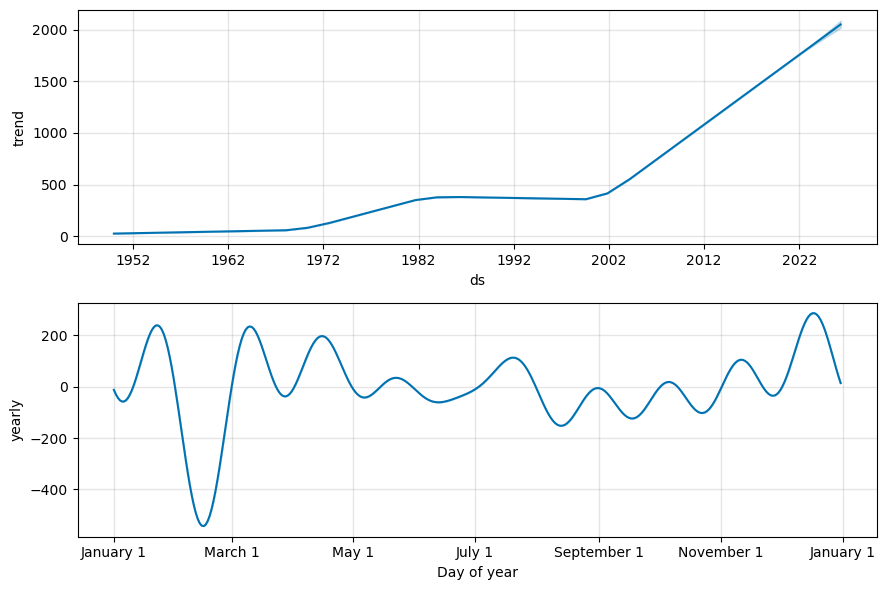

In [153]:
mp.plot_components(predp)
plt.show()